# Temporal Convolutional Networks (TCN) vs. ResNet for Modulation Classification (RadioML 2018.01A)

Automatic Modulation Classification (AMC) identifies the modulation scheme of a received radio signal (e.g., BPSK, 16QAM, FM) directly from raw I/Q data, with no prior channel information. Here, each input is a 1024-sample I/Q frame classified into one of 24 modulation categories.

This benchmark compares the baseline ResNet from the original RadioML paper (O'Shea et al., 2018) against three dilated TCN models scaled across compute budgets:
* `tcn_nano`: ≈0.25× ResNet MACs (≈6.5 MMACs)
* `tcn_small`: matched to the ResNet's compute (≈25.8 MMACs)
* `tcn_medium`: ≈2.0× ResNet MACs (≈52.9 MMACs)

The receptive field of each model is computed too, and the trained models are exported to ONNX and timed on CPU.


## 1. Setup

In [ ]:
!pip install -q onnx onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 131.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 36.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.


In [ ]:
import copy, math, os, shutil, time

import h5py
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Configuration & Checkpointing

Checkpoints and evaluation metrics are written directly to persistent storage. If a trained checkpoint exists in `OUT/ckpt`, it is loaded automatically instead of retraining (`REUSE_CKPT = True`).

In [ ]:
H5_DRIVE = "/content/drive/MyDrive/GOLD_XYZ_OSC.0001_1024.hdf5"
H5_LOCAL = "/content/GOLD_XYZ_OSC.0001_1024.hdf5"

RATIO        = 1.0     # fraction of every (class, snr) cell that is used, 1.0 = full dataset
SEED         = 42
EPOCHS       = 20
BATCH        = 256
LR           = 3e-3
WEIGHT_DECAY = 1e-2
USE_SE       = True    # squeeze-and-excitation inside the TCN blocks
RUN          = ["resnet", "tcn_nano", "tcn_small", "tcn_medium"]
REUSE_CKPT   = True
THREADS      = [1]  # cpu threads for the latency runs
LAT_RUNS     = 300

OUT = f"/content/drive/MyDrive/amc_tcn_vs_resnet/ratio{RATIO}_ep{EPOCHS}_seed{SEED}"

CLASSES = ["OOK", "4ASK", "8ASK", "BPSK", "QPSK", "8PSK", "16PSK", "32PSK",
           "16APSK", "32APSK", "64APSK", "128APSK", "16QAM", "32QAM", "64QAM",
           "128QAM", "256QAM", "AM-SSB-WC", "AM-SSB-SC", "AM-DSB-WC", "AM-DSB-SC",
           "FM", "GMSK", "OQPSK"]
SNRS  = list(range(-20, 32, 2))
N_CLS = len(CLASSES)
FRAME = 1024

for d in ("ckpt", "export", "figures"):
    os.makedirs(f"{OUT}/{d}", exist_ok=True)

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = dev.type == "cuda"
torch.backends.cudnn.benchmark = True
print(torch.__version__, dev, torch.cuda.get_device_name(0) if use_amp else "(no gpu, training will be very slow)")

2.11.0+cu128 cuda NVIDIA A100-SXM4-40GB


## 3. Signal Preprocessing

Inputs are raw 2-channel I/Q frames normalized by their frame RMS:

$$x_{\text{norm}} = \frac{x}{\sqrt{\frac{1}{L} \sum_{t=1}^{L} (I_t^2 + Q_t^2) + \epsilon}}$$

where $L = 1024$ is the frame length and $\epsilon = 10^{-8}$ avoids division by zero.

Normalization is applied during preprocessing. Exported ONNX models take pre-normalized inputs directly, avoiding runtime reduction operators in the graph.

In [ ]:
def rms_normalize(x):
    # x: [N, 2, L] raw i/q
    rms = x.pow(2).sum(1).mean(-1).add(1e-8).sqrt()
    return x / rms[:, None, None]

## 4. Dataset & In-Memory Caching

To bypass Google Drive I/O bottlenecks, the HDF5 file is cached to local disk before loading. Slices are read in chunks, normalized via RMS on the GPU, and retained in VRAM as FP16 tensors to fit the training set entirely in memory.

* **Split:** 70% train, 15% validation, 15% test.
* **Stratification:** Stratified across all (modulation class, SNR) bins to ensure balanced representation.

In [ ]:
if not os.path.exists(H5_LOCAL):
    shutil.copyfile(H5_DRIVE, H5_LOCAL)

In [ ]:
CHUNK = 16384

def load_dataset(path, ratio, seed):
    with h5py.File(path, "r") as f:
        n = f["X"].shape[0]
        y = np.empty(n, np.int64)
        snr = np.empty(n, np.int64)
        for s in range(0, n, 65536):
            y[s:s + 65536] = f["Y"][s:s + 65536].argmax(1)
            snr[s:s + 65536] = f["Z"][s:s + 65536].reshape(-1)

        if ratio >= 1.0:
            keep = np.arange(n)
        else:
            cell = y * len(SNRS) + (snr + 20) // 2
            rng = np.random.default_rng(seed)
            keep = np.sort(np.concatenate([
                rng.choice(np.flatnonzero(cell == c), int((cell == c).sum() * ratio), replace=False)
                for c in np.unique(cell)]))

        X = torch.empty((len(keep), 2, FRAME), dtype=torch.float16, device=dev)
        pos = 0
        for s in tqdm(range(0, n, CHUNK), desc="loading"):
            lo, hi = np.searchsorted(keep, [s, s + CHUNK])
            if hi == lo:
                continue
            blk = f["X"][s:s + CHUNK]                                  # [chunk, 1024, 2]
            x = torch.from_numpy(blk[keep[lo:hi] - s]).to(dev).permute(0, 2, 1)
            X[pos:pos + hi - lo] = rms_normalize(x).half()
            pos += hi - lo
    return X, y[keep], snr[keep].astype(np.int32)


t0 = time.time()
Xg, y, snr = load_dataset(H5_LOCAL, RATIO, SEED)
yg = torch.from_numpy(y).to(dev)
print(tuple(Xg.shape), f"{Xg.element_size() * Xg.nelement() / 1e9:.1f} GB on {dev}", f"{time.time() - t0:.0f}s")

loading:   0%|          | 0/156 [00:00<?, ?it/s]

(2555904, 2, 1024) 10.5 GB on cuda 43s


In [ ]:
cell = y * len(SNRS) + (snr + 20) // 2
ids = np.arange(len(y))
tr, rest = train_test_split(ids, test_size=0.30, stratify=cell, random_state=SEED)
va, te = train_test_split(rest, test_size=0.50, stratify=cell[rest], random_state=SEED)
print("train", len(tr), "val", len(va), "test", len(te))

train 1789132 val 383386 test 383386


## 5. Model Architectures

* **ResNet Baseline:** 1D adaptation from O'Shea et al. (2018). Six residual stacks (1×1 projection, two 3×3 residual units with BatchNorm, and MaxPool1D), fixed at 32 channels with a SELU/AlphaDropout dense head.
* **Dilated TCN:** A shared backbone across all three compute tiers:
  * **Stem:** 1D Conv ($k=7, s=4$) downsampling temporal length from 1024 to 256.
  * **Residual Blocks:** 5 blocks with exponentially increasing dilations ($d \in \{1, 2, 4, 8, 16\}$) using depthwise separable convolutions ($k=5$).
  * **Attention & Pooling:** Squeeze-and-Excitation (SE) channel attention per block, followed by concatenated Global Average + Max pooling into a linear classifier.

In [ ]:
class ResUnit(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv1d(ch, ch, 3, padding=1), nn.BatchNorm1d(ch), nn.ReLU(),
            nn.Conv1d(ch, ch, 3, padding=1), nn.BatchNorm1d(ch))

    def forward(self, x):
        return F.relu(x + self.f(x))


class ResNet1D(nn.Module):
    def __init__(self, in_ch=2, ch=32, stacks=6, n_cls=N_CLS):
        super().__init__()
        layers, c = [], in_ch
        for _ in range(stacks):
            layers += [nn.Conv1d(c, ch, 1), ResUnit(ch), ResUnit(ch), nn.MaxPool1d(2)]
            c = ch
        self.body = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(ch * (FRAME // 2 ** stacks), 128), nn.SELU(), nn.AlphaDropout(0.3),
            nn.Linear(128, 128), nn.SELU(), nn.AlphaDropout(0.3),
            nn.Linear(128, n_cls))

    def forward(self, x):
        return self.head(self.body(x))


class SE(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        hid = max(4, ch // r)
        self.fc1 = nn.Linear(ch, hid, bias=False)
        self.fc2 = nn.Linear(hid, ch, bias=False)

    def forward(self, x):
        w = torch.sigmoid(self.fc2(F.relu(self.fc1(x.mean(-1)))))
        return x * w.unsqueeze(-1)


def dw_sep(cin, cout, k, dil):
    pad = dil * (k - 1) // 2
    return nn.Sequential(
        nn.Conv1d(cin, cin, k, padding=pad, dilation=dil, groups=cin, bias=False),
        nn.Conv1d(cin, cout, 1, bias=False))


class TCNBlock(nn.Module):
    def __init__(self, cin, cout, dil, k=5, use_se=True):
        super().__init__()
        self.body = nn.Sequential(
            dw_sep(cin, cout, k, dil), nn.BatchNorm1d(cout), nn.ReLU(),
            dw_sep(cout, cout, k, dil), nn.BatchNorm1d(cout))
        self.se = SE(cout) if use_se else nn.Identity()
        self.skip = nn.Conv1d(cin, cout, 1, bias=False) if cin != cout else nn.Identity()

    def forward(self, x):
        return F.relu(self.se(self.body(x)) + self.skip(x))


class TCN(nn.Module):
    def __init__(self, chans, head, dils=(1, 2, 4, 8, 16), stem=32, stem_stride=4,
                 in_ch=2, n_cls=N_CLS, use_se=True):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_ch, stem, 7, stride=stem_stride, padding=3, bias=False),
            nn.BatchNorm1d(stem), nn.ReLU())
        blocks, c = [], stem
        for co, d in zip(chans, dils):
            blocks.append(TCNBlock(c, co, d, use_se=use_se))
            c = co
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.Linear(2 * c, head), nn.ReLU(), nn.Dropout(0.1), nn.Linear(head, n_cls))

    def forward(self, x):
        h = self.blocks(self.stem(x))
        h = torch.cat([h.mean(-1), h.amax(-1)], 1)
        return self.head(h)

In [ ]:
MODELS = {
    "resnet":     lambda: ResNet1D(),
    "tcn_nano":   lambda: TCN((32, 32, 40, 48, 56),    head=56,  use_se=USE_SE),
    "tcn_small":  lambda: TCN((56, 72, 80, 96, 112),   head=112, use_se=USE_SE),
    "tcn_medium": lambda: TCN((80, 96, 120, 144, 160), head=160, use_se=USE_SE),
}


def cost(model):
    # parameters and MACs per frame (conv + linear layers only)
    macs = [0]
    def on_conv(m, i, o): macs[0] += o.numel() * (m.in_channels // m.groups) * m.kernel_size[0]
    def on_fc(m, i, o):   macs[0] += m.in_features * m.out_features
    hooks = []
    for m in model.modules():
        if isinstance(m, nn.Conv1d): hooks.append(m.register_forward_hook(on_conv))
        if isinstance(m, nn.Linear): hooks.append(m.register_forward_hook(on_fc))
    model.eval()
    with torch.no_grad():
        model(torch.zeros(1, 2, FRAME))
    for h in hooks:
        h.remove()
    return sum(p.numel() for p in model.parameters()), macs[0] / 1e6


rows = []
for n in RUN:
    p, m = cost(MODELS[n]())
    rows.append(dict(model=n, params_k=p / 1e3, mmacs=m))
stats = pd.DataFrame(rows).set_index("model")
stats["vs_resnet"] = stats.mmacs / stats.loc["resnet", "mmacs"]

# the comparison only makes sense if tcn_small really sits at the resnet's compute
assert abs(stats.loc["tcn_small", "vs_resnet"] - 1) < 0.05, "tcn_small is not MAC-matched to the resnet"
stats.round(2)

,params_k,mmacs,vs_resnet
model,,,
resnet,166.68,25.94,1.00
tcn_nano,36.18,6.49,0.25
tcn_small,139.48,25.82,1.00
tcn_medium,283.10,52.89,2.04


## 6. Receptive Field

The theoretical receptive field (RF) is accumulated layer by layer:
`rf += (kernel - 1) * dilation * jump`
`jump *= stride`

* **TCN:** Stem ($k=7, s=4$) sets RF to 7 and jump to 4. Each block has two $k=5$ convs adding $32d$. Across $d \in \{1, 2, 4, 8, 16\}$, this adds 992, giving an RF of **999** (98% of the 1024-sample frame).
* **ResNet:** Each of the 6 stacks has four $3\times3$ convs and a MaxPool2, adding $9 \times \text{jump}$. Summing across jumps $1, 2, 4, 8, 16, 32$ gives $1 + 9 \times 63 = \mathbf{568}$ (55% of the frame).

In [ ]:
def receptive_field(model):
    # returns (rf in input samples, jump of the last feature map)
    rf, jump = 1, 1
    for m in model.modules():
        if isinstance(m, nn.Conv1d):
            k, s, d = m.kernel_size[0], m.stride[0], m.dilation[0]
        elif isinstance(m, nn.MaxPool1d):
            k, s, d = m.kernel_size, m.stride, 1
        else:
            continue
        rf += (k - 1) * d * jump
        jump *= s
    return rf, jump


for n in RUN:
    stats.loc[n, "rf"], stats.loc[n, "jump"] = receptive_field(MODELS[n]())
stats["rf_frac"] = stats.rf / FRAME
stats[["params_k", "mmacs", "vs_resnet", "rf", "jump", "rf_frac"]].round(2)

,params_k,mmacs,vs_resnet,rf,jump,rf_frac
model,,,,,,
resnet,166.68,25.94,1.00,568.0,64.0,0.55
tcn_nano,36.18,6.49,0.25,999.0,4.0,0.98
tcn_small,139.48,25.82,1.00,999.0,4.0,0.98
tcn_medium,283.10,52.89,2.04,999.0,4.0,0.98


## 7. Training

All models share the same training recipe and random seed:
* **Optimization:** AdamW, OneCycleLR schedule, gradient clipping at 1.0.
* **Precision:** FP16 mixed precision (`torch.autocast`).
* **Checkpointing:** Weights and training logs are saved to `OUT/ckpt`; the checkpoint with the highest validation accuracy is used for final test evaluation.

In [ ]:
def batches(ids, bs, shuffle=False, drop_last=False):
    ids = torch.as_tensor(ids, device=dev)
    if shuffle:
        ids = ids[torch.randperm(len(ids), device=dev)]
    stop = len(ids) - bs + 1 if drop_last else len(ids)
    for s in range(0, stop, bs):
        yield ids[s:s + bs]


@torch.no_grad()
def predict(model, ids):
    model.eval()
    out = [model(Xg[b].float()).float() for b in batches(ids, 1024)]
    return torch.cat(out).cpu()


def fit(name):
    torch.manual_seed(SEED)
    model = MODELS[name]().to(dev)
    steps = len(tr) // BATCH
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=EPOCHS * steps, pct_start=0.25)
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    y_val = yg[va].cpu()

    best_acc, best_state, log = 0.0, None, []
    for ep in range(1, EPOCHS + 1):
        t0 = time.time()
        model.train()
        loss_sum = torch.zeros((), device=dev)
        for b in batches(tr, BATCH, shuffle=True, drop_last=True):
            xb, yb = Xg[b].float(), yg[b]
            with torch.autocast(dev.type, dtype=torch.float16, enabled=use_amp):
                out = model(xb)
            loss = F.cross_entropy(out.float(), yb)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            sched.step()
            loss_sum += loss.detach()

        val_acc = (predict(model, va).argmax(1) == y_val).float().mean().item()
        sec = time.time() - t0
        log.append(dict(epoch=ep, loss=loss_sum.item() / steps, val_acc=val_acc, sec=sec))
        mark = ""
        if val_acc > best_acc:
            best_acc, mark = val_acc, " *"
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"{name} {ep:2d}/{EPOCHS}  loss {log[-1]['loss']:.3f}  val {val_acc * 100:.2f}  {sec:.0f}s{mark}")

    model.load_state_dict(best_state)
    log = pd.DataFrame(log)
    torch.save(best_state, f"{OUT}/ckpt/{name}.pt")
    log.to_csv(f"{OUT}/ckpt/{name}_log.csv", index=False)
    return model, log


def get_model(name):
    ckpt, logf = f"{OUT}/ckpt/{name}.pt", f"{OUT}/ckpt/{name}_log.csv"
    if REUSE_CKPT and os.path.exists(ckpt) and os.path.exists(logf):
        model = MODELS[name]().to(dev)
        model.load_state_dict(torch.load(ckpt, map_location=dev))
        print(f"{name}: loaded checkpoint from {ckpt}")
        return model, pd.read_csv(logf)
    return fit(name)

In [ ]:
trained, history = {}, {}
for name in RUN:
    trained[name], history[name] = get_model(name)

resnet  1/20  loss 1.766  val 44.73  186s *
resnet  2/20  loss 1.455  val 50.50  156s *
resnet  3/20  loss 1.373  val 55.09  156s *
resnet  4/20  loss 1.340  val 52.25  157s
resnet  5/20  loss 1.321  val 55.56  157s *
resnet  6/20  loss 1.304  val 55.48  156s
resnet  7/20  loss 1.289  val 57.09  156s *
resnet  8/20  loss 1.276  val 58.08  157s *
resnet  9/20  loss 1.265  val 58.21  156s *
resnet 10/20  loss 1.253  val 55.86  157s
resnet 11/20  loss 1.240  val 58.74  157s *
resnet 12/20  loss 1.227  val 59.28  158s *
resnet 13/20  loss 1.213  val 59.54  157s *
resnet 14/20  loss 1.199  val 60.55  157s *
resnet 15/20  loss 1.187  val 60.78  157s *
resnet 16/20  loss 1.174  val 61.23  157s *
resnet 17/20  loss 1.163  val 61.64  156s *
resnet 18/20  loss 1.154  val 61.76  157s *
resnet 19/20  loss 1.148  val 61.84  156s *
resnet 20/20  loss 1.144  val 61.94  157s *
tcn_nano  1/20  loss 1.995  val 40.39  120s *
tcn_nano  2/20  loss 1.610  val 46.96  102s *
tcn_nano  3/20  loss 1.384  val 53

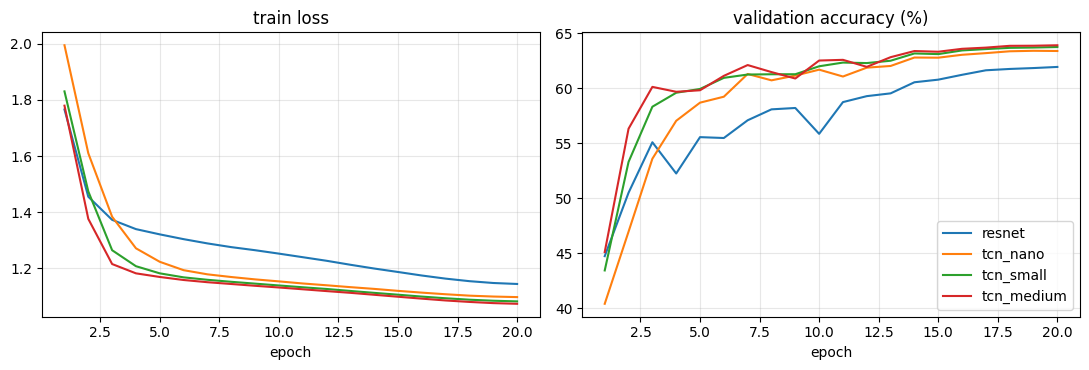

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for name, h in history.items():
    ax[0].plot(h.epoch, h.loss, label=name)
    ax[1].plot(h.epoch, h.val_acc * 100, label=name)
ax[0].set_title("train loss")
ax[1].set_title("validation accuracy (%)")
for a in ax:
    a.set_xlabel("epoch")
    a.grid(alpha=0.3)
ax[1].legend()
plt.tight_layout()
plt.savefig(f"{OUT}/figures/training_curves.png", dpi=130)
plt.show()

## 8. Effective Receptive Field (ERF)

Theoretical RF only indicates which input samples are reachable, not how much they actually contribute to the output. To measure this empirically:

1. Backpropagate from the center activation of the final feature map to the input across 512 test frames.
2. Average the absolute gradients across channels and frames.
3. Compute the **effective RF** as the minimum window containing 95% of the total gradient mass.

In [ ]:
def last_feature_map(model, x):
    if isinstance(model, ResNet1D):
        return model.body(x)
    return model.blocks(model.stem(x))


def effective_rf(model, ids, n=512, mass=0.95):
    model = copy.deepcopy(model).eval()
    x = Xg[torch.as_tensor(ids[:n], device=dev)].float().requires_grad_(True)
    fm = last_feature_map(model, x)
    fm[:, :, fm.shape[-1] // 2].sum().backward()

    g = x.grad.abs().sum(1).mean(0).cpu().numpy()                 # [L]
    cdf = np.cumsum(g / g.sum())
    lo = np.searchsorted(cdf, (1 - mass) / 2)
    hi = np.searchsorted(cdf, 1 - (1 - mass) / 2)
    return g, int(hi - lo + 1)


profiles = {}
for name in RUN:
    profiles[name], stats.loc[name, "eff_rf"] = effective_rf(trained[name], te)
stats["eff_frac"] = stats.eff_rf / FRAME
stats[["rf", "eff_rf", "rf_frac", "eff_frac"]].round(2)

,rf,eff_rf,rf_frac,eff_frac
model,,,,
resnet,568.0,237.0,0.55,0.23
tcn_nano,999.0,879.0,0.98,0.86
tcn_small,999.0,866.0,0.98,0.85
tcn_medium,999.0,877.0,0.98,0.86


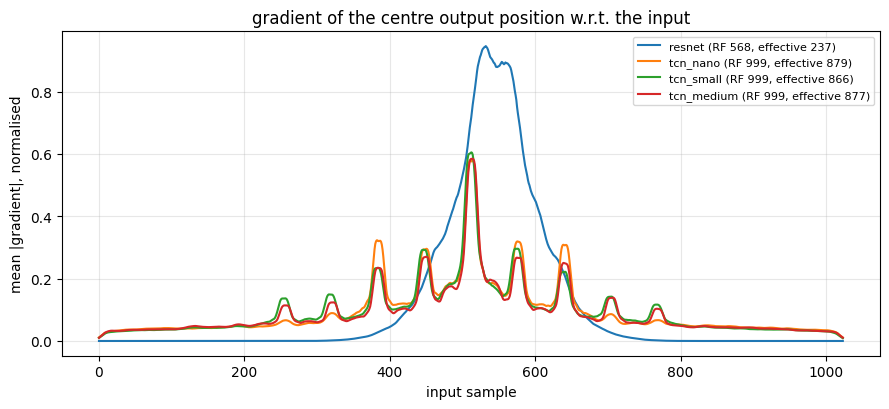

In [ ]:
plt.figure(figsize=(9, 4.2))
for name, g in profiles.items():
    smooth = np.convolve(g / g.max(), np.ones(16) / 16, mode="same")
    plt.plot(smooth, label=f"{name} (RF {int(stats.loc[name, 'rf'])}, effective {int(stats.loc[name, 'eff_rf'])})")
plt.xlabel("input sample")
plt.ylabel("mean |gradient|, normalised")
plt.title("gradient of the centre output position w.r.t. the input")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT}/figures/receptive_field.png", dpi=130)
plt.show()

## 9a. Test Accuracy & Metrics

* **`overall`:** Macro top-1 accuracy pooled across all test frames and SNR levels (-20 dB to +30 dB).
* **`mean_ge10`:** Mean per-SNR accuracy in the high-SNR regime ($\ge +10\text{ dB}$).
* **`ci95`:** 95% binomial confidence interval for test-set sampling ($\pm 0.15\%$ given $N \approx 383\text{k}$ frames). Note that this measures evaluation sampling uncertainty, not seed-to-seed training variance.

In [ ]:
y_te, snr_te = y[te], snr[te]
snr_arr = np.array(SNRS)

per_snr, rows = {}, []
for name, model in trained.items():
    pred = predict(model, te).argmax(1).numpy()
    ok = pred == y_te
    curve = np.array([ok[snr_te == s].mean() * 100 for s in SNRS])
    per_snr[name] = curve
    p = ok.mean()
    rows.append(dict(
        model=name,
        params_k=stats.loc[name, "params_k"],
        mmacs=stats.loc[name, "mmacs"],
        overall=p * 100,
        ci95=1.96 * math.sqrt(p * (1 - p) / len(ok)) * 100,
        at_m10=curve[snr_arr == -10][0],
        at_0=curve[snr_arr == 0][0],
        at_p10=curve[snr_arr == 10][0],
        mean_ge10=curve[snr_arr >= 10].mean(),
        best_val=history[name].val_acc.max() * 100,
        train_min=history[name].sec.sum() / 60))
acc = pd.DataFrame(rows).set_index("model").round(2)
acc.to_csv(f"{OUT}/accuracy.csv")
acc

,params_k,mmacs,overall,ci95,at_m10,at_0,at_p10,mean_ge10,best_val,train_min
model,,,,,,,,,,
resnet,166.68,25.94,61.82,0.15,14.74,55.02,95.77,96.53,61.94,52.74
tcn_nano,36.18,6.49,63.33,0.15,15.86,57.48,96.65,96.96,63.41,34.42
tcn_small,139.48,25.82,63.69,0.15,16.20,58.52,96.98,97.13,63.75,36.77
tcn_medium,283.10,52.89,63.88,0.15,16.26,58.95,97.02,97.18,63.91,38.30


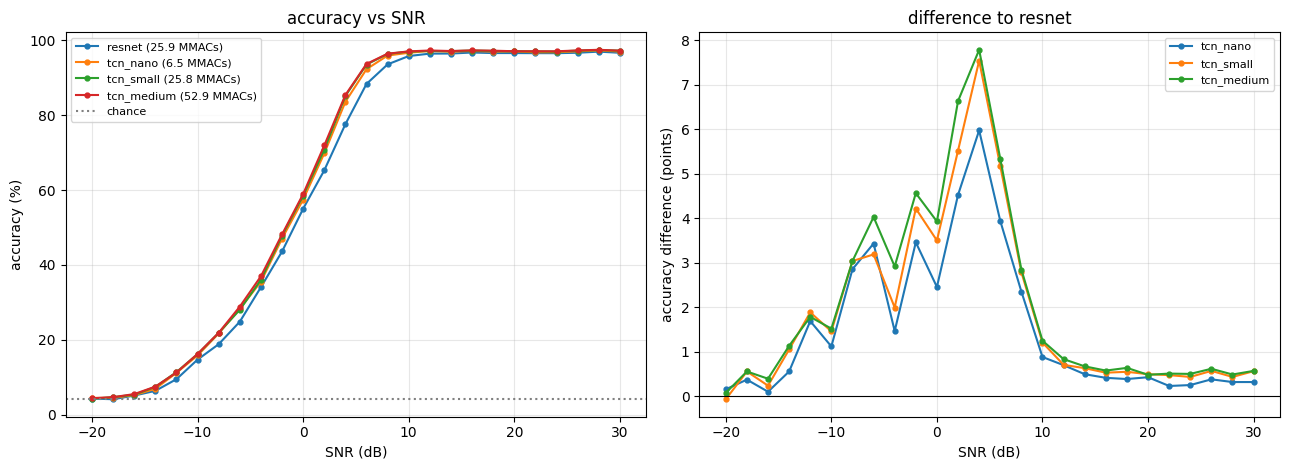

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for name, c in per_snr.items():
    ax[0].plot(SNRS, c, marker="o", ms=3.5, label=f"{name} ({stats.loc[name, 'mmacs']:.1f} MMACs)")
ax[0].axhline(100 / N_CLS, color="gray", ls=":", label="chance")
ax[0].set_title("accuracy vs SNR")
ax[0].set_ylabel("accuracy (%)")

for name, c in per_snr.items():
    if name != "resnet":
        ax[1].plot(SNRS, c - per_snr["resnet"], marker="o", ms=3.5, label=name)
ax[1].axhline(0, color="black", lw=0.8)
ax[1].set_title("difference to resnet")
ax[1].set_ylabel("accuracy difference (points)")

for a in ax:
    a.set_xlabel("SNR (dB)")
    a.grid(alpha=0.3)
    a.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT}/figures/snr_curves.png", dpi=130)
plt.show()

## 9b. Confusion matrices

Row-normalized confusion matrices evaluated at +10 to +30 dB (high-SNR regime, where errors are mostly class confusions rather than noise):
* **Class grouping:** Classes are ordered by modulation family and separated by gray lines.
* **Difference panel (`tcn_small` − `resnet`):** The rightmost plot shows the difference. Blue along the diagonal and red off-diagonal indicate where `tcn_small` performs better.
* **Summary statistics:** Printed below the figure to report per-class and per-family accuracy, intra-family error rates, and the most common confusions.

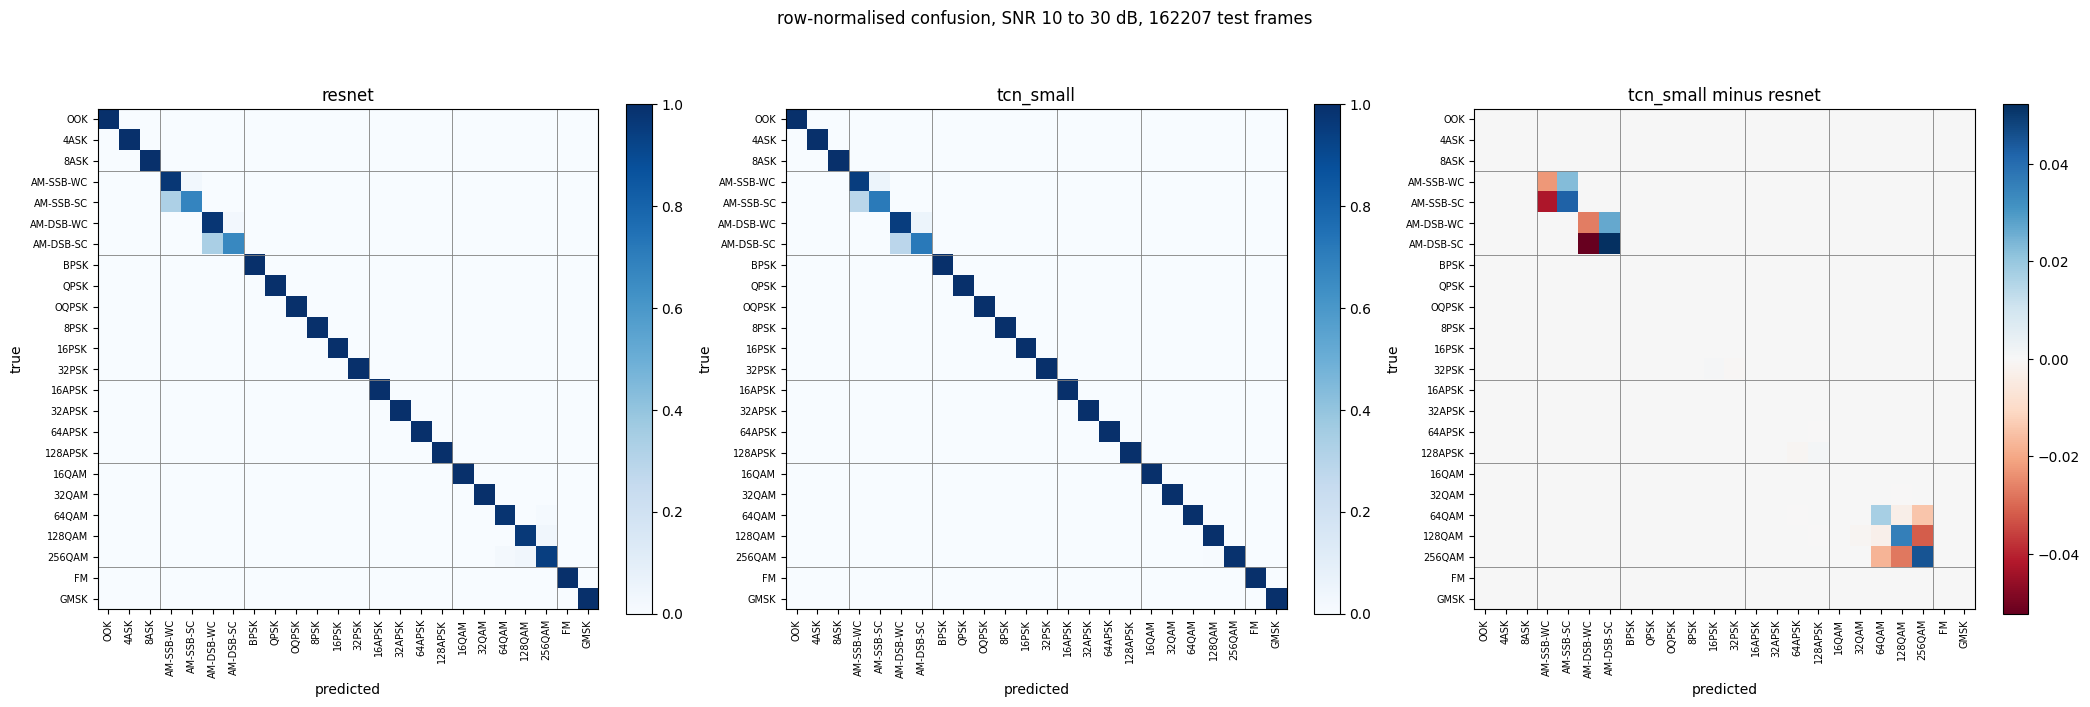

In [ ]:
CM_MODELS  = ("resnet", "tcn_small")   # pair shown as matrices
CM_MIN_SNR = 10                        # set both to 0 to look at 0 dB only
CM_MAX_SNR = 30

FAMILIES = {
    "ASK / OOK": ["OOK", "4ASK", "8ASK"],
    "analog AM": ["AM-SSB-WC", "AM-SSB-SC", "AM-DSB-WC", "AM-DSB-SC"],
    "PSK":       ["BPSK", "QPSK", "OQPSK", "8PSK", "16PSK", "32PSK"],
    "APSK":      ["16APSK", "32APSK", "64APSK", "128APSK"],
    "QAM":       ["16QAM", "32QAM", "64QAM", "128QAM", "256QAM"],
    "FM / GMSK": ["FM", "GMSK"],
}
ORDER  = [CLASSES.index(c) for cs in FAMILIES.values() for c in cs]
assert sorted(ORDER) == list(range(N_CLS))
LABELS = [CLASSES[i] for i in ORDER]
fam_names = list(FAMILIES)
fam_of = np.empty(N_CLS, dtype=object)
for f, cs in FAMILIES.items():
    for c in cs:
        fam_of[CLASSES.index(c)] = f
fam_id = np.array([fam_names.index(f) for f in fam_of])

y_te, snr_te = y[te], snr[te]
mask = (snr_te >= CM_MIN_SNR) & (snr_te <= CM_MAX_SNR)

preds = {n: predict(m, te).argmax(1).numpy() for n, m in trained.items()}


def confusion(pred):
    idx = y_te[mask] * N_CLS + pred[mask]
    cm = np.bincount(idx, minlength=N_CLS ** 2).reshape(N_CLS, N_CLS).astype(float)
    return cm / cm.sum(1, keepdims=True)          # rows: true class


cms = {n: confusion(p) for n, p in preds.items()}

a, b = CM_MODELS
M = lambda n: cms[n][np.ix_(ORDER, ORDER)]
diff = M(b) - M(a)
lim = np.abs(diff).max()
edges = np.cumsum([len(cs) for cs in FAMILIES.values()])[:-1] - 0.5

fig, ax = plt.subplots(1, 3, figsize=(21, 7))
panels = [(M(a), f"{a}", "Blues", 0, 1),
          (M(b), f"{b}", "Blues", 0, 1),
          (diff, f"{b} minus {a}", "RdBu", -lim, lim)]
for axis, (mat, title, cmap, lo, hi) in zip(ax, panels):
    im = axis.imshow(mat, cmap=cmap, vmin=lo, vmax=hi)
    axis.set_xticks(range(N_CLS)); axis.set_xticklabels(LABELS, rotation=90, fontsize=7)
    axis.set_yticks(range(N_CLS)); axis.set_yticklabels(LABELS, fontsize=7)
    for e in edges:
        axis.axhline(e, color="gray", lw=0.6)
        axis.axvline(e, color="gray", lw=0.6)
    axis.set_title(title)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    plt.colorbar(im, ax=axis, fraction=0.046)
fig.suptitle(f"row-normalised confusion, SNR {CM_MIN_SNR} to {CM_MAX_SNR} dB, {mask.sum()} test frames")
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.savefig(f"{OUT}/figures/confusion.png", dpi=130)
plt.show()

In [ ]:
per_class = pd.DataFrame({n: np.diag(cms[n]) * 100 for n in RUN}, index=CLASSES)
per_class.insert(0, "family", fam_of)
per_class = per_class.loc[LABELS]
per_class.round(1).to_csv(f"{OUT}/per_class_accuracy.csv")
display(per_class.round(1))

per_family = per_class.groupby("family").mean(numeric_only=True).loc[fam_names]
display(per_family.round(1))

,family,resnet,tcn_nano,tcn_small,tcn_medium
OOK,ASK / OOK,100.0,100.0,100.0,100.0
4ASK,ASK / OOK,100.0,100.0,100.0,100.0
8ASK,ASK / OOK,100.0,100.0,100.0,100.0
AM-SSB-WC,analog AM,97.1,94.5,94.8,94.9
AM-SSB-SC,analog AM,67.3,70.6,71.5,72.0
AM-DSB-WC,analog AM,97.3,93.8,94.6,94.5
AM-DSB-SC,analog AM,66.4,71.3,71.6,71.8
BPSK,PSK,100.0,100.0,100.0,100.0
QPSK,PSK,100.0,100.0,100.0,100.0
OQPSK,PSK,100.0,100.0,100.0,100.0


,resnet,tcn_nano,tcn_small,tcn_medium
family,,,,
ASK / OOK,100.0,100.0,100.0,100.0
analog AM,82.0,82.5,83.1,83.3
PSK,100.0,100.0,100.0,100.0
APSK,100.0,100.0,100.0,100.0
QAM,97.7,99.4,99.7,99.8
FM / GMSK,100.0,100.0,100.0,100.0


In [ ]:
rows = []
for n in RUN:
    err = mask & (preds[n] != y_te)
    same = fam_id[preds[n][err]] == fam_id[y_te[err]]
    rows.append(dict(model=n, errors=int(err.sum()), same_family_pct=100 * same.mean()))
display(pd.DataFrame(rows).set_index("model").round(1))


def top_confusions(cm, k=8):
    off = cm.copy()
    np.fill_diagonal(off, 0)
    flat = np.argsort(-off.ravel())[:k]
    return [(CLASSES[i // N_CLS], CLASSES[i % N_CLS], round(off.ravel()[i] * 100, 1)) for i in flat]


for n in CM_MODELS:
    print(n)
    display(pd.DataFrame(top_confusions(cms[n]), columns=["true", "predicted", "% of true class"]))

,errors,same_family_pct
model,,
resnet,5634,99.9
tcn_nano,4926,100.0
tcn_small,4662,100.0
tcn_medium,4582,100.0


resnet


,true,predicted,% of true class
0,AM-DSB-SC,AM-DSB-WC,33.6
1,AM-SSB-SC,AM-SSB-WC,32.7
2,256QAM,128QAM,3.5
3,128QAM,256QAM,3.5
4,AM-SSB-WC,AM-SSB-SC,2.9
5,AM-DSB-WC,AM-DSB-SC,2.7
6,256QAM,64QAM,2.0
7,64QAM,256QAM,1.6


tcn_small


,true,predicted,% of true class
0,AM-SSB-SC,AM-SSB-WC,28.5
1,AM-DSB-SC,AM-DSB-WC,28.4
2,AM-DSB-WC,AM-DSB-SC,5.4
3,AM-SSB-WC,AM-SSB-SC,5.2
4,256QAM,128QAM,0.8
5,128QAM,256QAM,0.3
6,256QAM,64QAM,0.3
7,64QAM,256QAM,0.1


## 10. Export & CPU Latency

* **Inference setup:** Single-frame latency (batch size = 1) measured with ONNX Runtime on CPU in FP32.
* **Numerical parity:** Validated on a fixed subset of 240 frames (10 per class):
  * `max_logit_diff`: Max absolute difference between PyTorch and ONNX logits; should remain $\le 10^{-4}$.
  * `pack_acc`: Accuracy on this 240-frame slice, reported strictly as an export sanity check rather than a test benchmark.

In [ ]:
# Hardware information was added post-hoc for documentation purposes.
# Captured hardware output during runtime:
# 'Intel(R) Xeon(R) CPU @ 2.20GHz'

# import subprocess
# def cpu_name():
#     cmd = "cat /proc/cpuinfo | grep 'model name' | uniq"
#     return subprocess.check_output(cmd, shell=True).decode().split(':')[1].strip()
# cpu_name()

'Intel(R) Xeon(R) CPU @ 2.20GHz'

In [ ]:
EXPORT = f"{OUT}/export"

rng = np.random.default_rng(0)
pack = np.concatenate([rng.choice(te[y[te] == c], 10, replace=False) for c in range(N_CLS)])
xp = Xg[torch.as_tensor(pack, device=dev)].float().cpu().numpy()          # [240, 2, 1024]
yp = y[pack]

ref = {}
for name in RUN:
    m = copy.deepcopy(trained[name]).cpu().eval()
    with torch.no_grad():
        ref[name] = m(torch.from_numpy(xp)).numpy()

    dummy = torch.zeros(1, 2, FRAME)
    kw = dict(input_names=["input"], output_names=["logits"], opset_version=17)
    try:
        torch.onnx.export(m, dummy, f"{EXPORT}/{name}.onnx", dynamo=False, **kw)
    except TypeError:
        torch.onnx.export(m, dummy, f"{EXPORT}/{name}.onnx", **kw)

sorted(os.listdir(EXPORT))

/tmp/ipykernel_4390/4164278873.py:17: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(m, dummy, f"{EXPORT}/{name}.onnx", dynamo=False, **kw)


['resnet.onnx', 'tcn_medium.onnx', 'tcn_nano.onnx', 'tcn_small.onnx']

In [ ]:
def make_session(name, threads):
    so = ort.SessionOptions()
    so.intra_op_num_threads = threads
    so.inter_op_num_threads = 1
    return ort.InferenceSession(f"{EXPORT}/{name}.onnx", so, providers=["CPUExecutionProvider"])


def latency(sess, x, n=LAT_RUNS, warmup=30):
    feed = {"input": x[None]}
    for _ in range(warmup):
        sess.run(None, feed)
    t = []
    for _ in range(n):
        t0 = time.perf_counter()
        sess.run(None, feed)
        t.append((time.perf_counter() - t0) * 1e3)
    return np.median(t), np.percentile(t, 95)


x0 = np.ascontiguousarray(xp[0])
bench = []
for name in RUN:
    for th in THREADS:
        sess = make_session(name, th)
        logits = np.stack([sess.run(None, {"input": x[None]})[0][0] for x in xp])
        med, p95 = latency(sess, x0)
        bench.append(dict(model=name, threads=th, median_ms=med, p95_ms=p95,
                          max_logit_diff=np.abs(logits - ref[name]).max(),
                          pack_acc=(logits.argmax(1) == yp).mean() * 100))
bench = pd.DataFrame(bench)
bench.to_csv(f"{OUT}/latency.csv", index=False)
bench.round(3)

,model,threads,median_ms,p95_ms,max_logit_diff,pack_acc
0,resnet,1,1.177,1.329,0.0,65.000
1,tcn_nano,1,0.526,0.540,0.0,67.083
2,tcn_small,1,1.128,1.146,0.0,67.500
3,tcn_medium,1,1.822,1.846,0.0,67.083


## 11. Summary

In [ ]:
lat = bench.pivot_table(index="model", columns="threads", values="median_ms")
lat.columns = [f"ort_{t}t_ms" for t in lat.columns]
size = pd.Series({n: os.path.getsize(f"{EXPORT}/{n}.onnx") / 1024 for n in RUN}, name="onnx_kb")

summary = (acc[["params_k", "mmacs", "overall", "ci95", "mean_ge10", "at_0"]]
           .join(stats[["rf", "eff_rf"]]).join(size).join(lat).round(2))
summary.to_csv(f"{OUT}/summary.csv")
summary

,params_k,mmacs,overall,ci95,mean_ge10,at_0,rf,eff_rf,onnx_kb,ort_1t_ms
model,,,,,,,,,,
resnet,166.68,25.94,61.82,0.15,96.53,55.02,568.0,237.0,658.54,1.18
tcn_nano,36.18,6.49,63.33,0.15,96.96,57.48,999.0,879.0,155.15,0.53
tcn_small,139.48,25.82,63.69,0.15,97.13,58.52,999.0,866.0,557.54,1.13
tcn_medium,283.10,52.89,63.88,0.15,97.18,58.95,999.0,877.0,1117.13,1.82


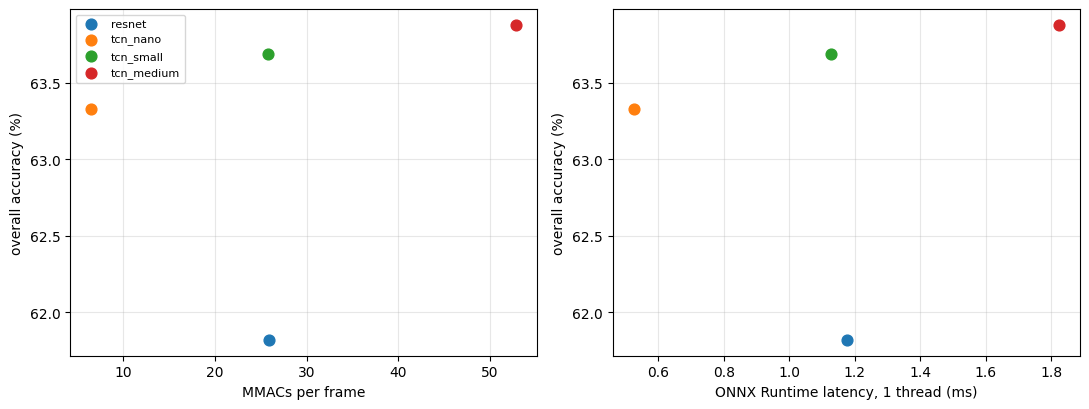

In [ ]:
lat1 = bench[bench.threads == 1].set_index("model").median_ms

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for i, name in enumerate(RUN):
    ax[0].scatter(stats.loc[name, "mmacs"], acc.loc[name, "overall"], s=60, color=f"C{i}", label=name)
    ax[1].scatter(lat1[name], acc.loc[name, "overall"], s=60, color=f"C{i}", label=name)
ax[0].set_xlabel("MMACs per frame")
ax[1].set_xlabel("ONNX Runtime latency, 1 thread (ms)")
for a in ax:
    a.set_ylabel("overall accuracy (%)")
    a.grid(alpha=0.3)
ax[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT}/figures/accuracy_vs_cost.png", dpi=130)
plt.show()